In [ ]:
!pip install -q imbalanced-learn transformers accelerate

In [ ]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120       # crisp inline figures on Colab

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_STATE   = 42
TEST_SIZE      = 0.30
MAX_SEQ_LEN    = 128
SLM_MODEL_NAME = "Thi-Thu-Huong/DDoSBert"
LR_MAX_ITER    = 1000
PCA_VARIANCE   = 0.95
N_FOLDS        = 5

# ── SLM Embedding Optimization Config ────────────────────────────────────────
USE_FP16       = True   # Use half precision for faster inference (minimal accuracy loss)
EMB_BATCH_SIZE = 128    # Increased batch size for better GPU utilization (adjust based on GPU memory)
ENABLE_COMPILE = True   # Use torch.compile() for PyTorch 2.0+ (faster inference)
CACHE_EMBEDDINGS = True # Cache embeddings to disk to avoid recomputation

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")
if USE_FP16 and DEVICE.type == "cuda":
    print(f"[INFO] FP16 optimization enabled for faster embeddings")
if ENABLE_COMPILE and hasattr(torch, "compile"):
    print(f"[INFO] torch.compile() enabled for optimized inference")

# ── Dataset paths — update to your Google Drive paths ─────────────────────────
DATASETS = {
    "CICDDoS2019": "/content/cicddos2019.csv",
    "AdDDoSDN"   : "/content/adddosdn_cicflow_dataset.csv",
}

[INFO] Using device: cuda
[INFO] FP16 optimization enabled for faster embeddings
[INFO] torch.compile() enabled for optimized inference


In [ ]:
def load_data(dataset_name, csv_path):
    print(f"\n[LOAD] Reading '{dataset_name}' from: {csv_path}")
    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()

    label_col = None
    for col in df.columns:
        if col.lower() in ("label", "class", "attack_type", "attack type"):
            label_col = col
            break
    if label_col is None:
        raise ValueError(f"No label column found. Columns: {list(df.columns)}")

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    y_raw = df[label_col]
    X = df.drop(columns=[label_col]).select_dtypes(include=[np.number])

    le = LabelEncoder()
    y  = pd.Series(le.fit_transform(y_raw), name="label")
    print(f"  → Shape: {X.shape}  |  Classes: {list(le.classes_)}")
    return X, y, le


In [ ]:
def preprocess_tabular(X_train, X_test, y_train):
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    print("  [PRE] SMOTE …")
    # Adapt k_neighbors to the smallest class size to avoid n_neighbors > n_samples_fit errors
    class_counts = np.bincount(y_train)
    min_count = class_counts[class_counts > 1].min()
    k_neighbors = max(1, min(5, min_count - 1))
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_train)
    print(f"       After SMOTE: {X_tr_sm.shape}  |  k_neighbors={k_neighbors}")

    pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
    X_tr_pca = pca.fit_transform(X_tr_sm)
    X_te_pca = pca.transform(X_te_sc)
    print(f"  [PRE] PCA → {pca.n_components_} components ({PCA_VARIANCE*100:.0f}% var)")
    return X_tr_pca, X_te_pca, y_tr_sm


In [ ]:
def build_prompts(X, feature_names):
    """Build prompts in the same dict-like format used to finetune DDoSBERT.

    Example target format:
    {"' ACK Flag Count': 0.0, ' URG Flag Count': 0.0, 'Flow Bytes/s': 0.842, ...}
    """
    prompts = []
    for row in X:
        # Each feature is formatted as: ' <feature_name>': value
        parts = [f"' {name}': {value:.3f}" for name, value in zip(feature_names, row)]
        prompt = "{" + ", ".join(parts) + "}"
        prompts.append(prompt)
    return prompts


def extract_slm_embeddings(prompts, tokenizer, model, batch_size=None, cache_key=None):
    """
    Optimized SLM embedding extraction with FP16, larger batches, and caching.

    Args:
        prompts: List of prompt strings
        tokenizer: HuggingFace tokenizer
        model: HuggingFace model
        batch_size: Batch size (defaults to EMB_BATCH_SIZE)
        cache_key: Optional cache key for saving/loading embeddings

    Returns:
        numpy array of embeddings
    """
    import hashlib
    import pickle
    import os

    if batch_size is None:
        batch_size = EMB_BATCH_SIZE

    # Check cache first
    if CACHE_EMBEDDINGS and cache_key:
        cache_dir = "./embedding_cache"
        os.makedirs(cache_dir, exist_ok=True)
        cache_file = os.path.join(cache_dir, f"{cache_key}.pkl")

        if os.path.exists(cache_file):
            print(f"  [CACHE] Loading embeddings from cache: {cache_file}")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)

    model.eval()

    # Model should already be optimized (FP16 + compiled) before calling this function
    # Check dtype for proper tensor handling
    is_fp16 = next(model.parameters()).dtype == torch.float16

    all_emb = []
    total_samples = len(prompts)

    with torch.no_grad():
        for s in range(0, total_samples, batch_size):
            batch = prompts[s : s + batch_size]

            # Tokenize with optimized settings
            enc = tokenizer(
                batch,
                max_length=MAX_SEQ_LEN,
                padding="max_length",  # Fixed length for better batching
                truncation=True,
                return_tensors="pt"
            )

            ids = enc["input_ids"].to(DEVICE)
            mask = enc["attention_mask"].to(DEVICE)

            # Forward pass with FP16 if enabled (model is already converted to half precision)
            out = model(input_ids=ids, attention_mask=mask)

            lh = out.last_hidden_state

            # Mean pooling with attention mask
            m_exp = mask.unsqueeze(-1).float()
            pooled = (lh * m_exp).sum(dim=1) / m_exp.sum(dim=1).clamp(min=1e-9)

            # Convert to float32 for numpy compatibility
            pooled = pooled.float().detach().cpu().numpy()
            all_emb.append(pooled)

            # Progress indicator for large datasets
            if (s + batch_size) % (batch_size * 10) == 0 or (s + batch_size) >= total_samples:
                print(f"  [EMB] Processed {min(s + batch_size, total_samples)}/{total_samples} samples", end='\r')

    result = np.vstack(all_emb)
    print()  # New line after progress

    # Save to cache
    if CACHE_EMBEDDINGS and cache_key:
        cache_dir = "./embedding_cache"
        os.makedirs(cache_dir, exist_ok=True)
        cache_file = os.path.join(cache_dir, f"{cache_key}.pkl")
        with open(cache_file, 'wb') as f:
            pickle.dump(result, f)
        print(f"  [CACHE] Saved embeddings to cache: {cache_file}")

    return result

In [ ]:
class AttentionFusionMLP(nn.Module):
    def __init__(self, dim_z, dim_e, hidden=128):
        super().__init__()
        self.W1 = nn.Linear(dim_z + dim_e, hidden)
        self.W2 = nn.Linear(hidden, 1)

    def forward(self, z, e):
        u = torch.cat([z, e], dim=1)
        w = torch.sigmoid(self.W2(torch.tanh(self.W1(u))))
        return torch.cat([w * z, (1.0 - w) * e], dim=1)


def fusion_attention(X_tr_pca, X_te_pca, E_tr, E_te,
                     hidden=128, epochs=5, lr=1e-3, batch_size=512):
    dim_z = X_tr_pca.shape[1];  dim_e = E_tr.shape[1]
    gate  = AttentionFusionMLP(dim_z, dim_e, hidden).to(DEVICE)
    opt   = torch.optim.Adam(gate.parameters(), lr=lr)
    crit  = nn.MSELoss()

    Z_tr = torch.tensor(X_tr_pca, dtype=torch.float32)
    E_tr_t = torch.tensor(E_tr,   dtype=torch.float32)
    N = Z_tr.shape[0]

    gate.train()
    for ep in range(epochs):
        perm   = torch.randperm(N)
        Z_tr   = Z_tr[perm];  E_tr_t = E_tr_t[perm]
        tot, steps = 0.0, 0
        for i in range(0, N, batch_size):
            zb = Z_tr[i:i+batch_size].to(DEVICE)
            eb = E_tr_t[i:i+batch_size].to(DEVICE)
            loss = crit(gate(zb, eb), torch.cat([zb, eb], dim=1))
            opt.zero_grad();  loss.backward();  opt.step()
            tot += loss.item();  steps += 1
        print(f"  [Hybrid] Epoch {ep+1}/{epochs}  loss={tot/steps:.6f}")

    gate.eval()
    with torch.no_grad():
        F_tr = gate(torch.tensor(X_tr_pca, dtype=torch.float32).to(DEVICE),
                    torch.tensor(E_tr,     dtype=torch.float32).to(DEVICE)
                    ).detach().cpu().numpy()
        F_te = gate(torch.tensor(X_te_pca, dtype=torch.float32).to(DEVICE),
                    torch.tensor(E_te,     dtype=torch.float32).to(DEVICE)
                    ).detach().cpu().numpy()
    return F_tr, F_te


def fusion_concatenation(X_tr_pca, X_te_pca, E_tr, E_te):
    """Simple concatenation fusion: [PCA features | SLM embeddings]"""
    F_tr = np.concatenate([X_tr_pca, E_tr], axis=1)
    F_te = np.concatenate([X_te_pca, E_te], axis=1)
    return F_tr, F_te

In [ ]:
def train_evaluate(X_tr, X_te, y_tr, y_te, variant_name):
    clf = LogisticRegression(max_iter=LR_MAX_ITER, random_state=RANDOM_STATE,
                             solver="lbfgs", multi_class="auto", n_jobs=-1)
    clf.fit(X_tr, y_tr)

    t0    = time.perf_counter()
    y_pred = clf.predict(X_te)
    ms_pp  = (time.perf_counter() - t0) * 1000 / len(y_te)

    avg  = "macro"
    res  = {
        "variant"                     : variant_name,
        "accuracy"                    : round(accuracy_score(y_te, y_pred), 4),
        "precision"                   : round(precision_score(y_te, y_pred, average=avg, zero_division=0), 4),
        "recall"                      : round(recall_score(y_te, y_pred, average=avg, zero_division=0), 4),
        "f1_score"                    : round(f1_score(y_te, y_pred, average=avg, zero_division=0), 4),
        "inference_time_ms_per_sample": round(ms_pp, 4),
    }
    print(f"\n  ── {variant_name} {'─'*40}")
    for k, v in res.items():
        print(f"     {k:<38}: {v}")
    return res, y_pred

In [ ]:
def run_hybrid_kfold(X_pca, E, y, dataset_name, n_folds=N_FOLDS):
    print(f"\n{'='*70}")
    print(f"  [KFOLD] PCA + SLM + Attention Fusion – {n_folds}-Fold CV on '{dataset_name}'")
    print(f"{'='*70}")

    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_pca, y), 1):
        print(f"\n  ── Fold {fold}/{n_folds} ────────────────────")
        F_tr, F_te = fusion_attention(X_pca[tr_idx], X_pca[te_idx],
                                      E[tr_idx],      E[te_idx])
        # Adapt k_neighbors to the smallest class size in this fold
        y_tr_fold = y[tr_idx]
        class_counts = np.bincount(y_tr_fold)
        min_count = class_counts[class_counts > 1].min()
        k_neighbors = max(1, min(5, min_count - 1))
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
        F_tr_sm, y_tr_sm = smote.fit_resample(F_tr, y_tr_fold)
        clf = LogisticRegression(max_iter=LR_MAX_ITER, random_state=RANDOM_STATE,
                                 solver="lbfgs", multi_class="auto", n_jobs=-1)
        clf.fit(F_tr_sm, y_tr_sm)
        yp  = clf.predict(F_te)
        avg = "macro"
        rec = {
            "fold"     : fold,
            "accuracy" : round(accuracy_score(y[te_idx], yp), 4),
            "precision": round(precision_score(y[te_idx], yp, average=avg, zero_division=0), 4),
            "recall"   : round(recall_score(y[te_idx], yp, average=avg, zero_division=0), 4),
            "f1_score" : round(f1_score(y[te_idx], yp, average=avg, zero_division=0), 4),
        }
        records.append(rec)
        print(f"     {rec}")

    df = pd.DataFrame(records)
    summary = {
        "fold"     : "MEAN ± STD",
        "accuracy" : f"{df['accuracy'].mean():.4f} ± {df['accuracy'].std():.4f}",
        "precision": f"{df['precision'].mean():.4f} ± {df['precision'].std():.4f}",
        "recall"   : f"{df['recall'].mean():.4f} ± {df['recall'].std():.4f}",
        "f1_score" : f"{df['f1_score'].mean():.4f} ± {df['f1_score'].std():.4f}",
    }
    print(f"\n  [KFOLD] Attention Fusion Summary → {summary}")
    return pd.concat([df, pd.DataFrame([summary])], ignore_index=True)


def run_concat_kfold(X_pca, E, y, dataset_name, n_folds=N_FOLDS):
    """K-Fold CV for PCA + SLM + Concatenation → LR"""
    print(f"\n{'='*70}")
    print(f"  [KFOLD] PCA + SLM + Concatenation – {n_folds}-Fold CV on '{dataset_name}'")
    print(f"{'='*70}")

    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_pca, y), 1):
        print(f"\n  ── Fold {fold}/{n_folds} (Concatenation) ────────────────────")
        F_tr, F_te = fusion_concatenation(X_pca[tr_idx], X_pca[te_idx],
                                          E[tr_idx],      E[te_idx])
        # Adapt k_neighbors to the smallest class size in this fold
        y_tr_fold = y[tr_idx]
        class_counts = np.bincount(y_tr_fold)
        min_count = class_counts[class_counts > 1].min()
        k_neighbors = max(1, min(5, min_count - 1))
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
        F_tr_sm, y_tr_sm = smote.fit_resample(F_tr, y_tr_fold)
        clf = LogisticRegression(max_iter=LR_MAX_ITER, random_state=RANDOM_STATE,
                                 solver="lbfgs", multi_class="auto", n_jobs=-1)
        clf.fit(F_tr_sm, y_tr_sm)
        yp  = clf.predict(F_te)
        avg = "macro"
        rec = {
            "fold"     : fold,
            "accuracy" : round(accuracy_score(y[te_idx], yp), 4),
            "precision": round(precision_score(y[te_idx], yp, average=avg, zero_division=0), 4),
            "recall"   : round(recall_score(y[te_idx], yp, average=avg, zero_division=0), 4),
            "f1_score" : round(f1_score(y[te_idx], yp, average=avg, zero_division=0), 4),
        }
        records.append(rec)
        print(f"     {rec}")

    df = pd.DataFrame(records)
    summary = {
        "fold"     : "MEAN ± STD",
        "accuracy" : f"{df['accuracy'].mean():.4f} ± {df['accuracy'].std():.4f}",
        "precision": f"{df['precision'].mean():.4f} ± {df['precision'].std():.4f}",
        "recall"   : f"{df['recall'].mean():.4f} ± {df['recall'].std():.4f}",
        "f1_score" : f"{df['f1_score'].mean():.4f} ± {df['f1_score'].std():.4f}",
    }
    print(f"\n  [KFOLD] Concatenation Summary → {summary}")
    return pd.concat([df, pd.DataFrame([summary])], ignore_index=True)


In [ ]:
def plot_confusion_matrices(y_test, predictions, class_names, dataset_name):
    """Display confusion matrices inline in Colab."""
    n  = len(predictions)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), constrained_layout=True)
    if n == 1:
        axes = [axes]

    fig.suptitle(f"Confusion Matrices — {dataset_name}", fontsize=14, fontweight="bold")
    display_labels = class_names if len(class_names) <= 10 else None

    for ax, (label, y_pred) in zip(axes, predictions.items()):
        cm   = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=display_labels)
        disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
        ax.set_title(label, fontsize=10)

    plt.show()

In [ ]:
def plot_tsne(X_raw, X_pca, E, F_fused, y, class_names, dataset_name,
              max_samples=3000):
    """Display t-SNE panels inline in Colab."""
    print(f"  [tSNE] Computing t-SNE for '{dataset_name}' …")
    N = len(y)
    idx = (np.random.RandomState(RANDOM_STATE).choice(N, max_samples, replace=False)
           if N > max_samples else np.arange(N))

    spaces = {
        "Raw (scaled)": X_raw[idx],
        "PCA"         : X_pca[idx],
        "SLM Embed"   : E[idx],
        "Hybrid Fused"  : F_fused[idx],
    }
    y_sub     = y[idx]
    n_classes = len(np.unique(y_sub))
    cmap      = plt.get_cmap("tab10" if n_classes <= 10 else "tab20")
    colors    = [cmap(i % cmap.N) for i in range(n_classes)]

    fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
    fig.suptitle(f"t-SNE Visualization — {dataset_name}", fontsize=14, fontweight="bold")

    for ax, (title, Xsp) in zip(axes, spaces.items()):
        tsne   = TSNE(n_components=2,
                      perplexity=min(30, len(idx)-1),
                      random_state=RANDOM_STATE,
                      n_iter=500, init="pca")
        coords = tsne.fit_transform(Xsp)

        for ci in range(n_classes):
            mask = y_sub == ci
            lbl  = class_names[ci] if ci < len(class_names) else str(ci)
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[colors[ci]], label=lbl, s=6, alpha=0.7)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("t-SNE 1");  ax.set_ylabel("t-SNE 2")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        if n_classes <= 10:
            ax.legend(fontsize=7, markerscale=3, loc="best")

    plt.show()

In [ ]:
def run_experiment(dataset_name, csv_path):
    print(f"\n{'='*70}\n  DATASET: {dataset_name}\n{'='*70}")

    # 1. Load
    X_raw, y, le  = load_data(dataset_name, csv_path)
    class_names   = list(le.classes_)
    feature_names = list(X_raw.columns)
    X_np = X_raw.values;  y_np = y.values

    # 2. Stratified split
    print("\n[SPLIT] Stratified 70/30 …")
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X_np, y_np, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y_np)
    print(f"  Train: {X_tr_raw.shape}  |  Test: {X_te_raw.shape}")

    # 3. Tabular preprocessing (with SMOTE + PCA)
    print("\n[PRE] Tabular preprocessing …")
    X_tr_pca, X_te_pca, y_tr_sm = preprocess_tabular(X_tr_raw, X_te_raw, y_tr)

    # 4. Prompts
    print("\n[EMB] Building prompts …")
    tr_prompts = build_prompts(X_tr_raw, feature_names)
    te_prompts = build_prompts(X_te_raw, feature_names)

    # 5. DDoSBert embeddings
    print(f"\n[EMB] Loading {SLM_MODEL_NAME} …")
    tokenizer  = AutoTokenizer.from_pretrained(SLM_MODEL_NAME)
    bert_model = AutoModel.from_pretrained(SLM_MODEL_NAME).to(DEVICE)
    bert_model.eval()

    # Optimize model once (FP16 + compile) before extracting embeddings
    if USE_FP16 and DEVICE.type == "cuda":
        bert_model = bert_model.half()
        print("  [OPT] Model converted to FP16 for faster inference")

    if ENABLE_COMPILE and hasattr(torch, "compile"):
        try:
            bert_model = torch.compile(bert_model, mode="reduce-overhead")
            print("  [OPT] Model compiled for optimized inference")
        except Exception as e:
            print(f"  [WARN] torch.compile() failed: {e}")

    # Generate cache keys based on dataset name and data hash
    import hashlib
    train_hash = hashlib.md5(str(X_tr_raw.shape).encode() + str(y_tr[:100]).encode()).hexdigest()[:8]
    test_hash = hashlib.md5(str(X_te_raw.shape).encode() + str(y_te[:100]).encode()).hexdigest()[:8]
    cache_key_train = f"{dataset_name}_train_{train_hash}"
    cache_key_test = f"{dataset_name}_test_{test_hash}"

    print("[EMB] Extracting train embeddings …")
    E_tr = extract_slm_embeddings(tr_prompts, tokenizer, bert_model, cache_key=cache_key_train)
    print("[EMB] Extracting test embeddings …")
    E_te = extract_slm_embeddings(te_prompts, tokenizer, bert_model, cache_key=cache_key_test)

    # Non-SMOTE PCA features aligned with original rows (for SLM variants)
    print("\n[PRE] Non-SMOTE scaled PCA …")
    sc_ns = StandardScaler()
    X_tr_ns = sc_ns.fit_transform(X_tr_raw);  X_te_ns = sc_ns.transform(X_te_raw)
    pca_ns  = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
    X_tr_pca_ns = pca_ns.fit_transform(X_tr_ns)
    X_te_pca_ns = pca_ns.transform(X_te_ns)

    all_results = {};  predictions = {}

    # ── A: Baseline
    print("\n\n[A] Baseline: PCA + LR")
    res_A, yp_A = train_evaluate(X_tr_pca, X_te_pca, y_tr_sm, y_te,
                                 "(A) Baseline: PCA + LR")
    all_results["A"] = res_A;  predictions["(A) Baseline"] = yp_A

    # ── B: SLM-only (with SMOTE)
    print("\n\n[B] SLM-only: Embeddings + LR (with SMOTE)")
    # Adapt k_neighbors to the smallest class size for SLM-only
    class_counts_B = np.bincount(y_tr)
    min_count_B = class_counts_B[class_counts_B > 1].min()
    k_neighbors_B = max(1, min(5, min_count_B - 1))
    smote_B = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors_B)
    E_tr_sm, y_tr_sm_B = smote_B.fit_resample(E_tr, y_tr)
    res_B, yp_B = train_evaluate(E_tr_sm, E_te, y_tr_sm_B, y_te,
                                 "(B) SLM-only: Embeddings + LR (SMOTE)")
    all_results["B"] = res_B;  predictions["(B) SLM-only (SMOTE)"] = yp_B

    # ── C: Hybrid with Attention Fusion
    print("\n\n[C] PCA Features + SLM Embeddings + Attention Fusion Mechanism + LR (with SMOTE)")
    F_tr, F_te = fusion_attention(X_tr_pca_ns, X_te_pca_ns, E_tr, E_te)
    # Adapt k_neighbors to the smallest class size for Hybrid
    class_counts_C = np.bincount(y_tr)
    min_count_C = class_counts_C[class_counts_C > 1].min()
    k_neighbors_C = max(1, min(5, min_count_C - 1))
    smote_C = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors_C)
    F_tr_sm, y_tr_sm_C = smote_C.fit_resample(F_tr, y_tr)
    res_C, yp_C = train_evaluate(F_tr_sm, F_te, y_tr_sm_C, y_te,
                                 "(C) PCA Features + SLM Embeddings + Attention Fusion → LR (SMOTE)")
    all_results["C"] = res_C;  predictions["(C) PCA + SLM + Attention Fusion (SMOTE)"] = yp_C

    # ── D: Hybrid with Concatenation
    print("\n\n[D] PCA Features + SLM Embeddings + Concatenation + LR (with SMOTE)")
    F_concat_tr, F_concat_te = fusion_concatenation(X_tr_pca_ns, X_te_pca_ns, E_tr, E_te)
    # Adapt k_neighbors to the smallest class size for Concatenation
    class_counts_D = np.bincount(y_tr)
    min_count_D = class_counts_D[class_counts_D > 1].min()
    k_neighbors_D = max(1, min(5, min_count_D - 1))
    smote_D = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors_D)
    F_concat_tr_sm, y_tr_sm_D = smote_D.fit_resample(F_concat_tr, y_tr)
    res_D, yp_D = train_evaluate(F_concat_tr_sm, F_concat_te, y_tr_sm_D, y_te,
                                 "(D) PCA Features + SLM Embeddings + Concatenation → LR (SMOTE)")
    all_results["D"] = res_D;  predictions["(D) PCA + SLM + Concatenation (SMOTE)"] = yp_D

    # 7. Confusion Matrices → shown inline
    print(f"\n[PLOT] Confusion matrices for '{dataset_name}' …")
    plot_confusion_matrices(y_te, predictions, class_names, dataset_name)

    # 8. 5-Fold CV for Concatenation fusion variant (on training portion)
    df_kfold_concat = run_concat_kfold(X_tr_pca_ns, E_tr, y_tr, dataset_name)
    print(f"\n[KFOLD] {dataset_name} — PCA + SLM + Concatenation 5-Fold Results:")
    print(df_kfold_concat.to_string(index=False))

    # 9. t-SNE → shown inline
    print(f"\n[PLOT] t-SNE for '{dataset_name}' …")
    plot_tsne(X_tr_ns, X_tr_pca_ns, E_tr, F_tr, y_tr, class_names, dataset_name)

    df_results = pd.DataFrame(list(all_results.values()))
    df_results.insert(0, "dataset", dataset_name)
    # Return Concatenation k-fold by default
    return df_results, df_kfold_concat


  DATASET: CICDDoS2019

[LOAD] Reading 'CICDDoS2019' from: /content/cicddos2019.csv
  → Shape: (50000, 78)  |  Classes: ['Benign', 'DrDoS_DNS', 'DrDoS_LDAP', 'DrDoS_MSSQL', 'DrDoS_NTP', 'DrDoS_NetBIOS', 'DrDoS_SNMP', 'DrDoS_UDP', 'LDAP', 'MSSQL', 'NetBIOS', 'Portmap', 'Syn', 'TFTP', 'UDP', 'UDP-lag', 'UDPLag', 'WebDDoS']

[SPLIT] Stratified 70/30 …
  Train: (35000, 78)  |  Test: (15000, 78)

[PRE] Tabular preprocessing …
  [PRE] SMOTE …
       After SMOTE: (178002, 78)  |  k_neighbors=5
  [PRE] PCA → 17 components (95% var)

[EMB] Building prompts …

[EMB] Loading Thi-Thu-Huong/DDoSBert …


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: Thi-Thu-Huong/DDoSBert
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [OPT] Model converted to FP16 for faster inference
  [OPT] Model compiled for optimized inference
[EMB] Extracting train embeddings …


W0305 06:03:00.709000 4856 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


  [EMB] Processed 35000/35000 samples
  [CACHE] Saved embeddings to cache: ./embedding_cache/CICDDoS2019_train_07fc75e1.pkl
[EMB] Extracting test embeddings …
  [EMB] Processed 15000/15000 samples
  [CACHE] Saved embeddings to cache: ./embedding_cache/CICDDoS2019_test_edc21b77.pkl

[PRE] Non-SMOTE scaled PCA …


[A] Baseline: PCA + LR

  ── (A) Baseline: PCA + LR ────────────────────────────────────────
     variant                               : (A) Baseline: PCA + LR
     accuracy                              : 0.9612
     precision                             : 0.7389
     recall                                : 0.9312
     f1_score                              : 0.779
     inference_time_ms_per_sample          : 0.0003


[B] SLM-only: Embeddings + LR (with SMOTE)

  ── (B) SLM-only: Embeddings + LR (SMOTE) ────────────────────────────────────────
     variant                               : (B) SLM-only: Embeddings + LR (SMOTE)
     accuracy                              : 0.9705
 

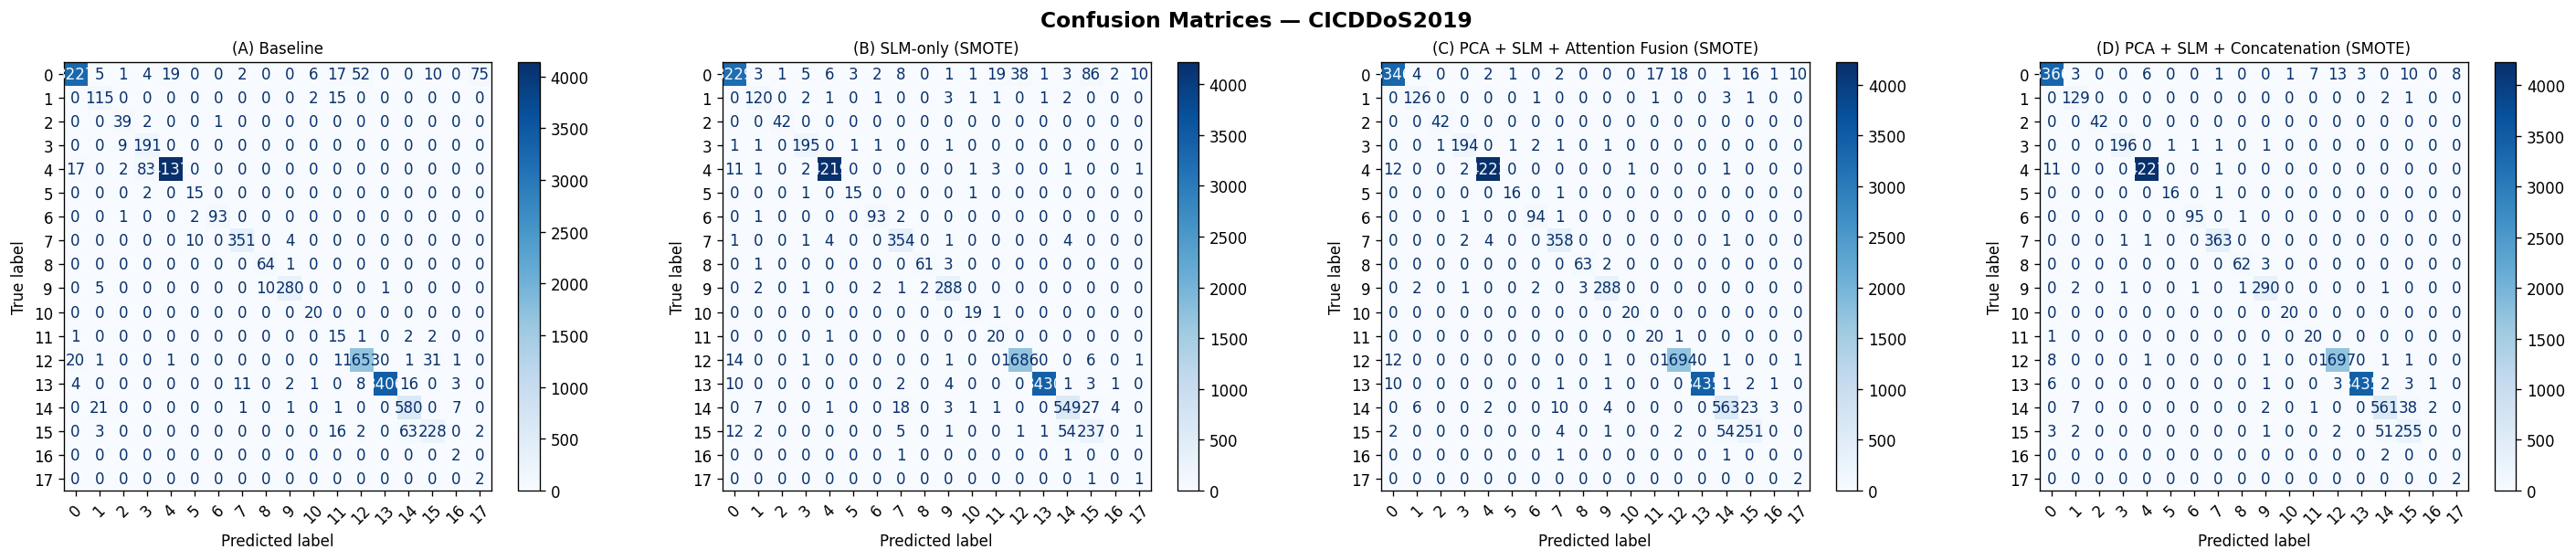


  [KFOLD] PCA + SLM + Concatenation – 5-Fold CV on 'CICDDoS2019'

  ── Fold 1/5 (Concatenation) ────────────────────
     {'fold': 1, 'accuracy': 0.9837, 'precision': 0.8411, 'recall': 0.9027, 'f1_score': 0.8611}

  ── Fold 2/5 (Concatenation) ────────────────────
     {'fold': 2, 'accuracy': 0.9819, 'precision': 0.8333, 'recall': 0.9062, 'f1_score': 0.8619}

  ── Fold 3/5 (Concatenation) ────────────────────
     {'fold': 3, 'accuracy': 0.9833, 'precision': 0.8601, 'recall': 0.899, 'f1_score': 0.8724}

  ── Fold 4/5 (Concatenation) ────────────────────
     {'fold': 4, 'accuracy': 0.9829, 'precision': 0.8456, 'recall': 0.9161, 'f1_score': 0.8642}

  ── Fold 5/5 (Concatenation) ────────────────────
     {'fold': 5, 'accuracy': 0.981, 'precision': 0.8586, 'recall': 0.9379, 'f1_score': 0.8772}

  [KFOLD] Concatenation Summary → {'fold': 'MEAN ± STD', 'accuracy': '0.9826 ± 0.0011', 'precision': '0.8477 ± 0.0115', 'recall': '0.9124 ± 0.0156', 'f1_score': '0.8674 ± 0.0071'}

[KFOLD] CICDDo

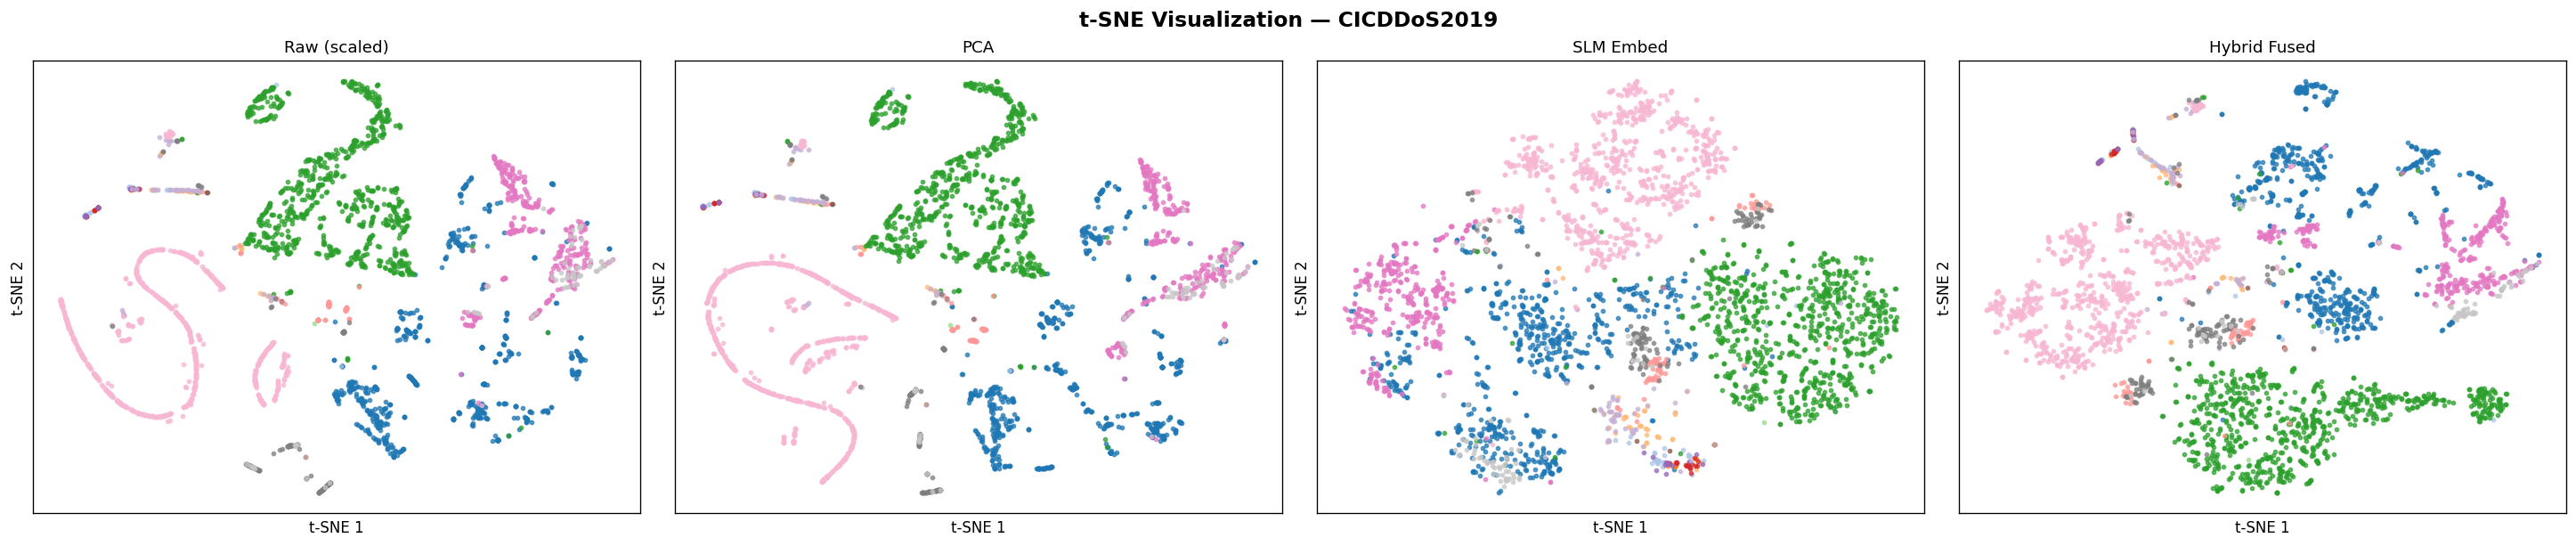


  DATASET: AdDDoSDN

[LOAD] Reading 'AdDDoSDN' from: /content/adddosdn_cicflow_dataset.csv
  → Shape: (268887, 81)  |  Classes: ['ad_slow', 'ad_syn', 'ad_udp', 'icmp_flood', 'normal', 'syn_flood', 'udp_flood']

[SPLIT] Stratified 70/30 …
  Train: (188220, 81)  |  Test: (80667, 81)

[PRE] Tabular preprocessing …
  [PRE] SMOTE …
       After SMOTE: (434623, 81)  |  k_neighbors=5
  [PRE] PCA → 15 components (95% var)

[EMB] Building prompts …

[EMB] Loading Thi-Thu-Huong/DDoSBert …


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: Thi-Thu-Huong/DDoSBert
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [OPT] Model converted to FP16 for faster inference
  [OPT] Model compiled for optimized inference
[EMB] Extracting train embeddings …

  [CACHE] Saved embeddings to cache: ./embedding_cache/AdDDoSDN_train_2416c198.pkl
[EMB] Extracting test embeddings …
  [EMB] Processed 80667/80667 samples
  [CACHE] Saved embeddings to cache: ./embedding_cache/AdDDoSDN_test_b52766be.pkl

[PRE] Non-SMOTE scaled PCA …


[A] Baseline: PCA + LR

  ── (A) Baseline: PCA + LR ────────────────────────────────────────
     variant                               : (A) Baseline: PCA + LR
     accuracy                              : 0.9572
     precision                             : 0.949
     recall                                : 0.9721
     f1_score                              : 0.9569
     inference_time_ms_per_sample          : 0.0001


[B] SLM-only: Embeddings + LR (with SMOTE)

  ── (B) SLM-only: Embeddings + LR (SMOTE) ────────────────────────────────────────
     variant                               

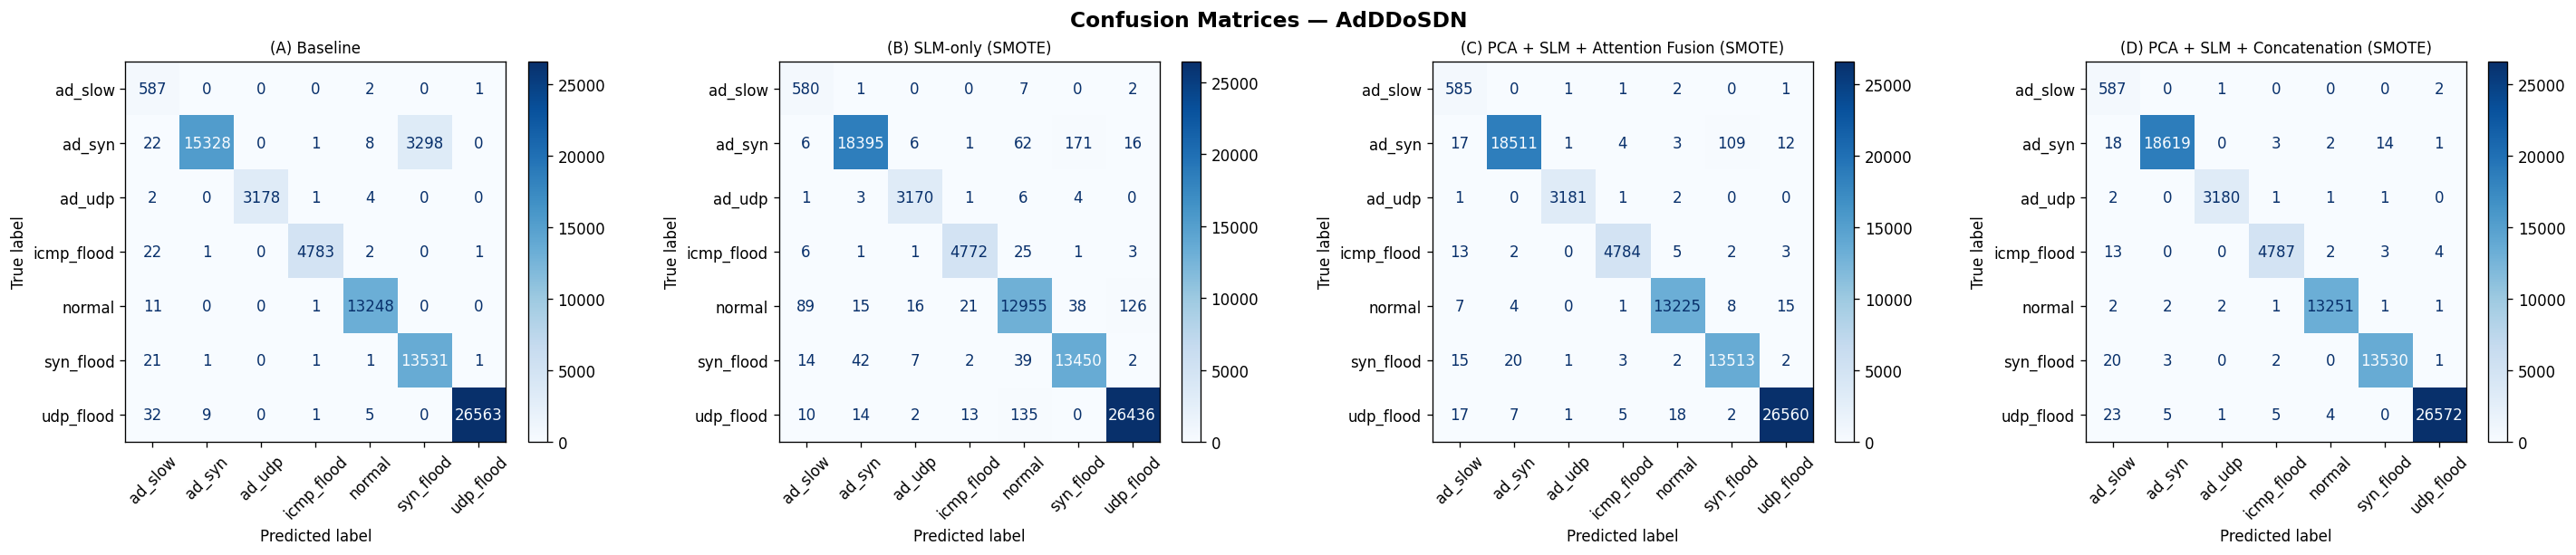


  [KFOLD] PCA + SLM + Concatenation – 5-Fold CV on 'AdDDoSDN'

  ── Fold 1/5 (Concatenation) ────────────────────
     {'fold': 1, 'accuracy': 0.9985, 'precision': 0.9879, 'recall': 0.9967, 'f1_score': 0.9922}

  ── Fold 2/5 (Concatenation) ────────────────────
     {'fold': 2, 'accuracy': 0.9977, 'precision': 0.9824, 'recall': 0.9955, 'f1_score': 0.9886}

  ── Fold 3/5 (Concatenation) ────────────────────
     {'fold': 3, 'accuracy': 0.9979, 'precision': 0.982, 'recall': 0.9961, 'f1_score': 0.9886}

  ── Fold 4/5 (Concatenation) ────────────────────
     {'fold': 4, 'accuracy': 0.9983, 'precision': 0.9828, 'recall': 0.9965, 'f1_score': 0.9893}

  ── Fold 5/5 (Concatenation) ────────────────────
     {'fold': 5, 'accuracy': 0.9986, 'precision': 0.9895, 'recall': 0.9977, 'f1_score': 0.9935}

  [KFOLD] Concatenation Summary → {'fold': 'MEAN ± STD', 'accuracy': '0.9982 ± 0.0004', 'precision': '0.9849 ± 0.0035', 'recall': '0.9965 ± 0.0008', 'f1_score': '0.9904 ± 0.0023'}

[KFOLD] AdDDoSDN

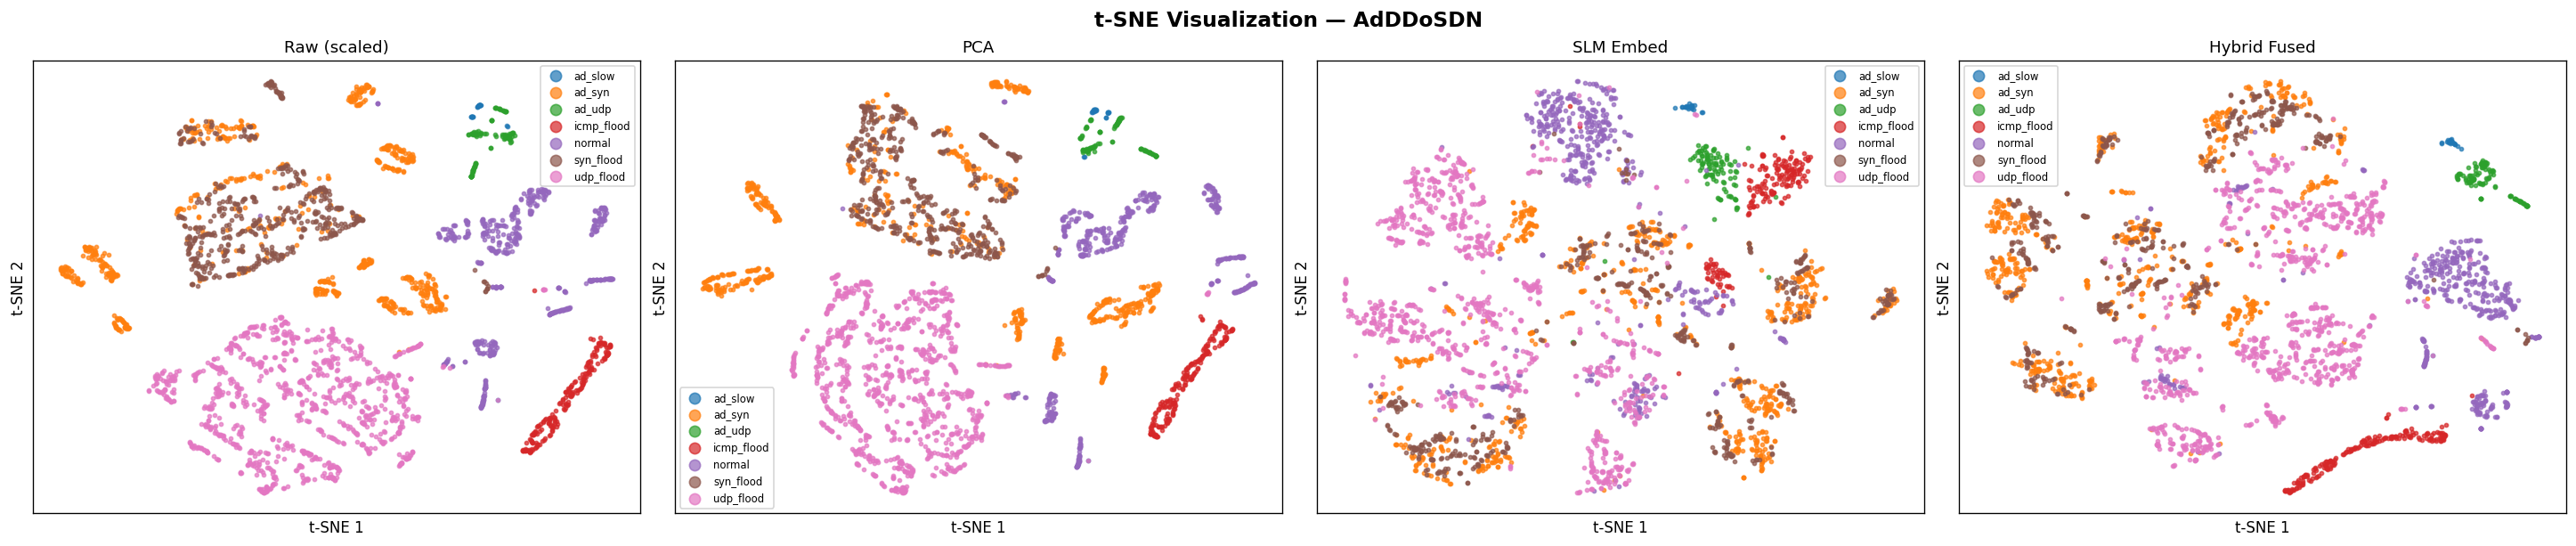



  FINAL RESULTS SUMMARY  (70/30 split — Variants A, B, C, D)
    dataset                                                           variant  accuracy  precision  recall  f1_score  inference_time_ms_per_sample
CICDDoS2019                                            (A) Baseline: PCA + LR    0.9612     0.7389  0.9312    0.7790                        0.0003
CICDDoS2019                             (B) SLM-only: Embeddings + LR (SMOTE)    0.9705     0.7858  0.8663    0.8111                        0.0034
CICDDoS2019 (C) PCA Features + SLM Embeddings + Attention Fusion → LR (SMOTE)    0.9823     0.8293  0.9113    0.8494                        0.0035
CICDDoS2019    (D) PCA Features + SLM Embeddings + Concatenation → LR (SMOTE)    0.9851     0.8510  0.9149    0.8671                        0.0018
   AdDDoSDN                                            (A) Baseline: PCA + LR    0.9572     0.9490  0.9721    0.9569                        0.0001
   AdDDoSDN                             (B) SLM-only: E

,dataset,variant,accuracy,precision,recall,f1_score,inference_time_ms_per_sample
0,CICDDoS2019,(A) Baseline: PCA + LR,0.961200,0.738900,0.931200,0.779000,0.000300
1,CICDDoS2019,(B) SLM-only: Embeddings + LR (SMOTE),0.970500,0.785800,0.866300,0.811100,0.003400
2,CICDDoS2019,(C) PCA Features + SLM Embeddings + Attention Fusion → LR (SMOTE),0.982300,0.829300,0.911300,0.849400,0.003500
3,CICDDoS2019,(D) PCA Features + SLM Embeddings + Concatenation → LR (SMOTE),0.985100,0.851000,0.914900,0.867100,0.001800
4,AdDDoSDN,(A) Baseline: PCA + LR,0.957200,0.949000,0.972100,0.956900,0.000100
5,AdDDoSDN,(B) SLM-only: Embeddings + LR (SMOTE),0.988700,0.965400,0.988500,0.975900,0.003000
6,AdDDoSDN,(C) PCA Features + SLM Embeddings + Attention Fusion → LR (SMOTE),0.996200,0.982100,0.995700,0.988500,0.003400
7,AdDDoSDN,(D) PCA Features + SLM Embeddings + Concatenation → LR (SMOTE),0.998300,0.982300,0.997500,0.989400,0.001300


In [ ]:
all_dfs    = []
all_kfolds = []

for name, path in DATASETS.items():
    if not os.path.isfile(path):
        print(f"[WARN] CSV not found: {path}  →  skipping '{name}'")
        continue
    df, df_kf = run_experiment(name, path)
    all_dfs.append(df)
    all_kfolds.append((name, df_kf))

if all_dfs:
    final = pd.concat(all_dfs, ignore_index=True)
    print("\n\n" + "="*70)
    print("  FINAL RESULTS SUMMARY  (70/30 split — Variants A, B, C, D)")
    print("="*70)
    print(final.to_string(index=False))

    # Optional: display as styled DataFrame in Colab notebook
    try:
        from IPython.display import display
        display(final.style.highlight_max(
            subset=["accuracy","precision","recall","f1_score"],
            color="lightgreen", axis=0
        ))
    except Exception:
        pass
else:
    print("\n[ERROR] No datasets processed. Check your CSV paths in DATASETS dict.")